# Exploratory Data Analysis using the Pokemon Dataset

<img src="https://img.itch.zone/aW1nLzM0MzUxOTUuanBn/original/FuMxog.jpg" />

In [35]:
import kagglehub
import os
import pandas as pd

In [ ]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

In [ ]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


In [ ]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


`.describe()`	Summary stats (mean, std, min, max, percentiles)

In [ ]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


## 1. Central tendency 

Get the mean attack of all pokemons using `.mean()`

In [ ]:
df['Attack'].mean()

np.float64(79.00125)

Get the middle number of all pokemons attack values using `.median()`

In [ ]:
df['Attack'].median()

75.0

Get the most frequent attack value of all pokemons using `.mode()`	

In [ ]:
df['Attack'].mode()

,Attack
0,100


## 2. Dispersion 

Get the minimum value of Attack using `df.min()`

In [ ]:
df['Attack'].min()

5

Get the minimum value of Attack using `df.max()`

In [ ]:
df['Attack'].max()

190

Compute standard deviation of Speed using `.std()`

In [ ]:
df['Speed'].std()

29.06047371716149

Compute variance of Speed using `.var()`

In [ ]:
df['Speed'].var()

844.5111326658338

Percentiles using `.quantile()`	

In [ ]:
print(df['HP'].quantile(0.25))
print(df['HP'].quantile(0.5))
print(df['HP'].quantile(0.75))

50.0
65.0
80.0


## 3. Skewness and Kurtosis

Check assymetry of HP 

In [ ]:
df['HP'].skew()

np.float64(7.232078374375156)

Check the peakedness or tailedness of HP 

In [ ]:
df['HP'].kurt() 

np.float64(1.5682243758418617)

## 4. Filtering

1. Use `.query()` to show Pokémon with Attack > 120.

In [ ]:
df.query('Attack > 120')

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
19,15,BeedrillMega Beedrill,Bug,Poison,495,65,150,40,15,80,145,1,False
74,68,Machamp,Fighting,NaN,505,90,130,80,65,85,55,1,False
107,99,Kingler,Water,NaN,475,55,130,115,50,50,75,1,False
120,112,Rhydon,Ground,Rock,485,105,130,120,45,45,40,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,697,Tyrantrum,Rock,Dragon,521,82,121,119,69,59,71,6,False
792,716,Xerneas,Fairy,NaN,680,126,131,95,131,98,99,6,True
793,717,Yveltal,Dark,Flying,680,126,131,95,131,98,99,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True


2. Use `.query()` to show Pokémon that are both **Fire-type** AND **Fast (Speed > 100)**.

In [ ]:
df.query('`Type 1` == "Fire" and Speed > 100')

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
84,78,Rapidash,Fire,NaN,500,65,100,70,80,80,105,1,False
437,392,Infernape,Fire,Fighting,534,76,104,71,104,71,108,4,False
573,514,Simisear,Fire,NaN,498,75,98,63,98,63,101,5,False
723,655,Delphox,Fire,Psychic,534,75,69,72,114,100,104,6,False
731,663,Talonflame,Fire,Flying,499,78,81,71,74,69,126,6,False
736,668,Pyroar,Fire,Normal,507,86,68,72,109,66,106,6,False


3. Select only Name, Type 1, Attack, Speed.

In [ ]:
df[['Name', 'Type 1', 'Attack', 'Speed']].query('`Type 1` == "Fire" and Speed > 100')

,Name,Type 1,Attack,Speed
84,Rapidash,Fire,100,105
437,Infernape,Fire,104,108
573,Simisear,Fire,98,101
723,Delphox,Fire,69,104
731,Talonflame,Fire,81,126
736,Pyroar,Fire,68,106


4. Use `query()` to get all Water-type Pokémon.

In [ ]:
df.query('`Type 1` == "Water"')

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False
10,8,Wartortle,Water,NaN,405,59,63,80,65,80,58,1,False
11,9,Blastoise,Water,NaN,530,79,83,100,85,105,78,1,False
12,9,BlastoiseMega Blastoise,Water,NaN,630,79,103,120,135,115,78,1,False
59,54,Psyduck,Water,NaN,320,50,52,48,65,50,55,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,656,Froakie,Water,NaN,314,41,56,40,62,44,71,6,False
725,657,Frogadier,Water,NaN,405,54,63,52,83,56,97,6,False
726,658,Greninja,Water,Dark,530,72,95,67,103,71,122,6,False
762,692,Clauncher,Water,NaN,330,50,53,62,58,63,44,6,False


## 5. Categorical Exploration

1. Count Pokémon per Type 1.

In [ ]:
df['Type 1'].value_counts()

,count
Type 1,
Water,112
Normal,98
Grass,70
Bug,69
Psychic,57
Fire,52
Rock,44
Electric,44
Ground,32


2. Display the top 3 most common Type 2 values.

In [ ]:
df['Type 2'].value_counts().head(3)

,count
Type 2,
Flying,97
Ground,35
Poison,34


3. Compute percentage distribution of generations.

In [ ]:
df_generation_count = pd.DataFrame((df['Generation'].value_counts() / df['Generation'].value_counts().sum()) * 100)
df_generation_count.reset_index(inplace=True)

In [ ]:
df_generation_count.head()

,Generation,count
0,1,20.750
1,5,20.625
2,3,20.000
3,4,15.125
4,2,13.250


<!-- 

`.corr()`	Correlation matrix

`.cov()`	Covariance -->

<Axes: title={'center': 'Percentage of Pokemons by Generation'}, ylabel='Generation'>

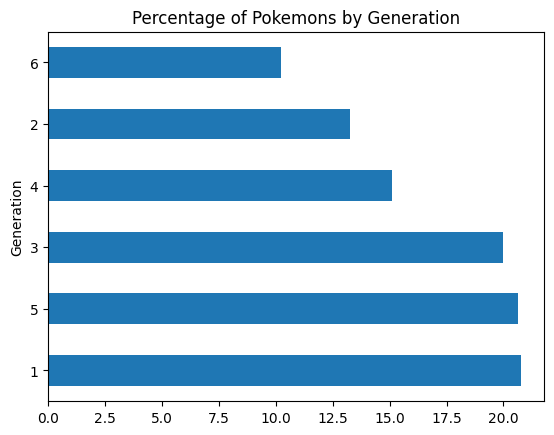

In [ ]:
df_generation_count.plot.barh(x='Generation', y='count', legend=False, title='Percentage of Pokemons by Generation')

## 6. GroupBy and & Aggregation


1. Find average stats per Type 1.

In [ ]:
df.groupby('Type 1')['Total'].mean()

,Total
Type 1,
Bug,378.927536
Dark,445.741935
Dragon,550.531250
Electric,443.409091
Fairy,413.176471
Fighting,416.444444
Fire,458.076923
Flying,485.000000
Ghost,439.562500


2. Which Type 1 has the highest average Speed?

In [ ]:
df.groupby('Type 1')['Speed'].mean().sort_values(ascending=False)

,Speed
Type 1,
Flying,102.500000
Electric,84.500000
Dragon,83.031250
Psychic,81.491228
Dark,76.161290
Fire,74.442308
Normal,71.551020
Fighting,66.074074
Water,65.964286


3. Create a pivot table for Generation vs Legendary count.

In [ ]:
table = df.groupby('Generation')['Legendary'].value_counts()

In [ ]:
table

Generation  Legendary
1           False        160
            True           6
2           False        101
            True           5
3           False        142
            True          18
4           False        108
            True          13
5           False        150
            True          15
6           False         74
            True           8
Name: count, dtype: int64

In [ ]:
legendary_df = df.query('Legendary == True')

table2 = pd.pivot_table(legendary_df, index =['Generation'], values=['Legendary'], aggfunc ='count')
table2

,Legendary
Generation,
1,6
2,5
3,18
4,13
5,15
6,8
